In [34]:
import pandas as pd
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import joblib
from sklearn.feature_selection import  SelectKBest, f_classif

# Load train data
df = pd.read_csv('train_with_clusters.csv')
df.columns = df.columns.str.strip().str.replace(' ', '_')


# Select ClusterID
cluster_id = 7
subgroup_df = df[df['ClusterID'] == cluster_id]

print(f"Number of samples in Cluster {cluster_id}:", len(subgroup_df))

Number of samples in Cluster 7: 7


In [35]:

# Drop target variable and unnecessary columns before scaling
X = subgroup_df.drop(columns=['Bankrupt?', 'Index', 'ClusterID'])
y = subgroup_df['Bankrupt?']


In [36]:
# Feature Extraction

selector = SelectKBest(score_func= f_classif, k=1)
selector.fit(X, y)
selected_features = X.columns[selector.get_support()]
X_reduced=X[selected_features]
with open(f"selected_features_cluster{cluster_id}.txt", 'w') as f:
    for feat in selected_features:
        f.write(f"{feat}\n")
print(f'Reduced {X.shape[1]-X_reduced.shape[1]} features, {X_reduced.shape[1]} feature left\n')

Reduced 94 features, 1 feature left



/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [11 84 93] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [37]:
from sklearn.utils import resample

# Perform scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)

# Oversampling
X_scaled_df = pd.DataFrame(X_scaled, columns=X_reduced.columns, index=X_reduced.index)
X_scaled_df['Bankrupt?'] = y  # Add the target variable back to do Oversampling

df_minority = X_scaled_df[X_scaled_df['Bankrupt?'] == 1]
df_majority = X_scaled_df[X_scaled_df['Bankrupt?'] == 0]

df_minority_upsampled = resample(df_minority,
                                 replace=True,
                                 n_samples=len(df_majority),
                                 random_state=42)



# Combine majority and upsampled minority
df_balanced = pd.concat([df_majority, df_minority_upsampled])
print(df_balanced.shape)
print(df_balanced['Bankrupt?'].value_counts())


(12, 2)
Bankrupt?
0    6
1    6
Name: count, dtype: int64


In [38]:
X_balanced=df_balanced.drop(columns=['Bankrupt?']).values
y_balanced=df_balanced['Bankrupt?']

In [39]:

# Base Model
base_models = [
    ('decision_tree', DecisionTreeClassifier(random_state=42)),
    ('svc',SVC(kernel='poly', degree=3,probability=True, random_state=42)),
    ('knn', KNeighborsClassifier()),
]

# Meta Model
meta_model =MLPClassifier(max_iter=1000, random_state=42)

# Build stacking model with cross-validation inside
stacked_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5  # 5-fold cross-validation
)

# Train the stacking model
stacked_model.fit(X_balanced, y_balanced)

StackingClassifier(cv=5,
                   estimators=[('decision_tree',
                                DecisionTreeClassifier(random_state=42)),
                               ('svc',
                                SVC(kernel='poly', probability=True,
                                    random_state=42)),
                               ('knn', KNeighborsClassifier())],
                   final_estimator=MLPClassifier(max_iter=1000,
                                                 random_state=42))

In [40]:

fitted_base_models=[]
for name, model in base_models:
    model.fit(X_balanced, y_balanced)
    fitted_base_models.append((name, model))


# Predict base models
tt_total=0
tf_total=0
pred_base={}
for name, model in fitted_base_models:

    y_pred = model.predict(X_scaled)
    pred_base[name]=y_pred
    tt_curr = sum((y == 1) & (y_pred == 1))
    tf_curr = sum((y == 1) & (y_pred == 0))

    acc_curr = tt_curr/(tf_curr + tt_curr)

    tt_total+=tt_curr
    tf_total+=tf_curr

    print(f"Base model {name}: accuracy={acc_curr:.2f} [{tt_curr}({tf_curr})]")


total_acc=tt_total/(tf_total + tt_total)
print(f"Total accuracy of Base Model={total_acc:.2f} [{tt_total}({tf_total})]")



# Predict meta model
y_pred_meta = stacked_model.predict(X_scaled)
tt_meta = sum((y == 1) & (y_pred_meta == 1))
tf_meta = sum((y == 1) & (y_pred_meta == 0))

acc_meta = tt_meta/(tf_meta + tt_meta)
print(f"Meta model: accuracy={acc_meta:.2f} [{tt_meta}({tf_meta})]")



Base model decision_tree: accuracy=1.00 [1(0)]
Base model svc: accuracy=1.00 [1(0)]
Base model knn: accuracy=1.00 [1(0)]
Total accuracy of Base Model=1.00 [3(0)]
Meta model: accuracy=1.00 [1(0)]


In [41]:

# Step 9: Save the trained scaler and stacking model
joblib.dump(scaler, f'scaler_cluster{cluster_id}.pkl')
joblib.dump(stacked_model, f'stacked_model_cluster{cluster_id}.pkl')

print(f"Scaler and stacking model for Cluster {cluster_id} saved.")

Scaler and stacking model for Cluster 7 saved.


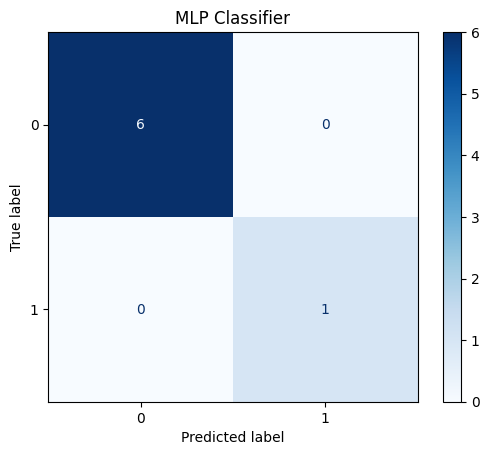


Classification Report:
                  precision    recall  f1-score   support

Not Bankrupt (0)       1.00      1.00      1.00         6
    Bankrupt (1)       1.00      1.00      1.00         1

        accuracy                           1.00         7
       macro avg       1.00      1.00      1.00         7
    weighted avg       1.00      1.00      1.00         7



In [42]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Step 1: Generate Confusion Matrix
cm = confusion_matrix(y, y_pred_meta)

# Step 2: Visualize Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title('MLP Classifier')
plt.show()

# Step 3: Print Precision, Recall, F1-Score
print("\nClassification Report:")
print(classification_report(y, y_pred_meta, target_names=["Not Bankrupt (0)", "Bankrupt (1)"]))


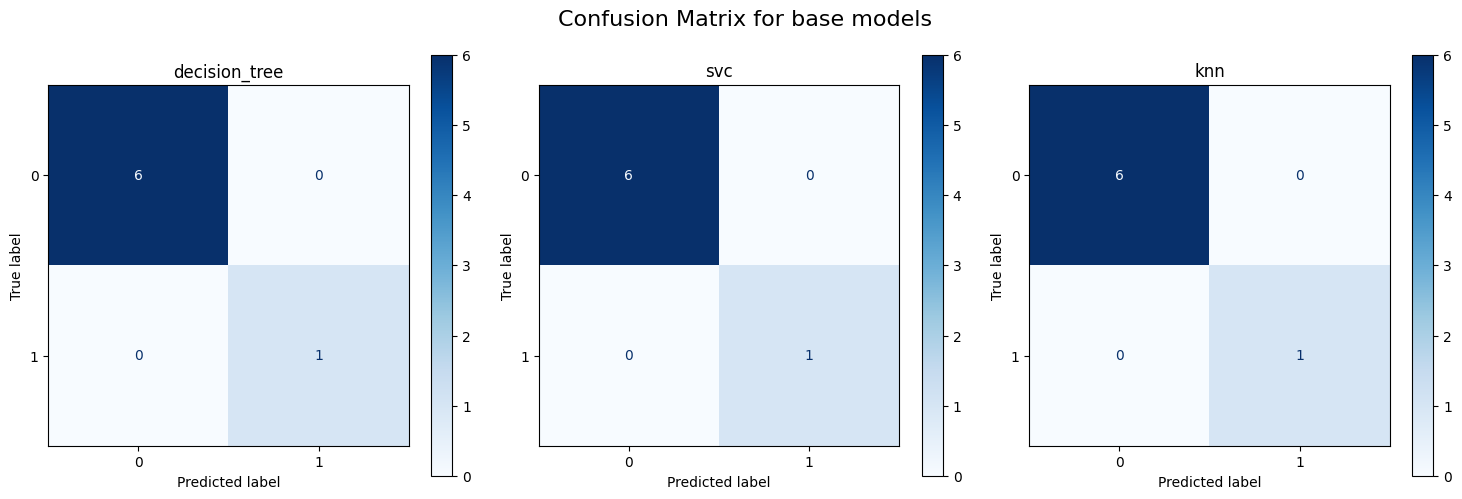

In [43]:
# Generate Confusion Matrix for base models

num_cols = 3  # Number of columns in the subplot grid
num_rows = 1  # Number of rows in the subplot grid


fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))  # Create subplots grid
axes = axes.flatten()  # Flatten the axes array for easier indexing
names=[item[0] for item in fitted_base_models]
for i in range(len(fitted_base_models)):
    name=names[i]

    cm = confusion_matrix(y, pred_base[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap='Blues',ax=axes[i])


    axes[i].set_title(f'{name}')

fig.suptitle('Confusion Matrix for base models', fontsize=16)
plt.tight_layout()
plt.show()



# 3.2.3. Identify unique or helpful characteristics in each subgroup. Visualize.
Features that are important for one cluster may have following characteristics:

## 1. Unique from other clusters. This means the value of this feature is high in this cluster, but low in other cluster.

## 2. Common within same cluster. The values of this feature have low variance within this cluster.
## 3. Relevant to target 'bankrupt?'

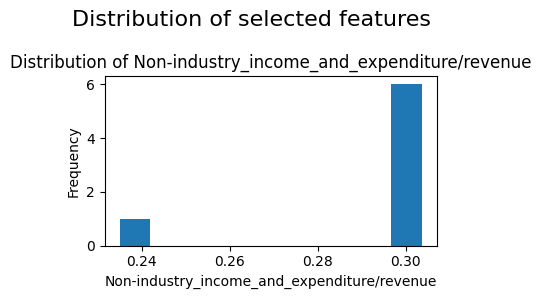

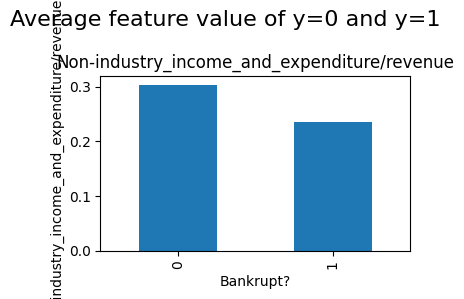

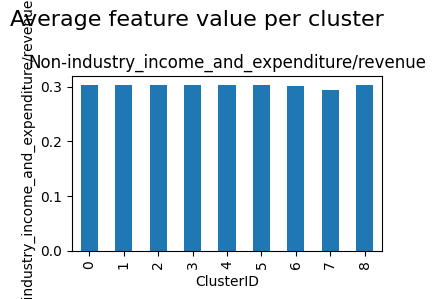

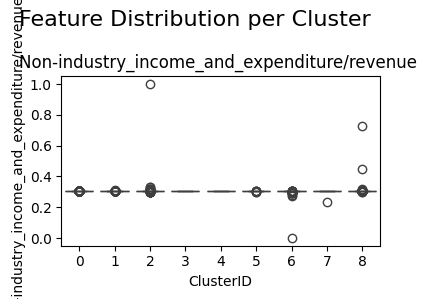

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np



def visualize():

    num_cols = len(selected_features)  # Number of columns in the subplot grid
    num_rows = 1

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))  # Create subplots grid

    if not isinstance(axes, (np.ndarray)):
        axes = np.array([axes])
    axes = axes.flatten()  # Flatten the axes array for easier indexing
    for  i in range(len(selected_features)):
        feature=selected_features[i]
        # Plot histograms
        axes[i].hist(X[feature], bins=10)
        plt.tight_layout()
        axes[i].set_title(f'Distribution of {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Frequency')

    fig.suptitle('Distribution of selected features', fontsize=16)
    plt.tight_layout()

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))  # Create subplots grid

    if not isinstance(axes, (np.ndarray)):
        axes = np.array([axes])
    axes = axes.flatten()  # Flatten the axes array for easier indexing
    for i, feature in enumerate(selected_features):
        feature_mean = subgroup_df.groupby('Bankrupt?')[feature].mean()

        feature_mean.plot(kind='bar', ax=axes[i])
        axes[i].set_title(f'{feature}')
        axes[i].set_xlabel('Bankrupt?')
        axes[i].set_ylabel(feature)
    fig.suptitle('Average feature value of y=0 and y=1', fontsize=16)
    plt.tight_layout()

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))
    if not isinstance(axes, (np.ndarray)):
        axes = np.array([axes])
    # axes = axes.flatten()

    for i, feature in enumerate(selected_features):

        mean_feature = df.groupby('ClusterID')[feature].mean()
        mean_feature.plot(kind='bar', ax=axes[i])  # Plot on the corresponding subplot
        axes[i].set_title(f'{feature}')
        axes[i].set_xlabel('ClusterID')
        axes[i].set_ylabel(feature)
    fig.suptitle('Average feature value per cluster', fontsize=16)
    plt.tight_layout()

    # Step 5: Plot boxplots for feature distributions across clusters using subplots
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))
    if not isinstance(axes, (np.ndarray)):
        axes = np.array([axes])
    axes = axes.flatten()

    for i, feature in enumerate(selected_features):
        sns.boxplot(x='ClusterID', y=feature, data=df, ax=axes[i])
        axes[i].set_title(f'{feature} ')
        axes[i].set_xlabel('ClusterID')
        axes[i].set_ylabel(feature)
    fig.suptitle('Feature Distribution per Cluster', fontsize=16)
    plt.tight_layout()
    plt.show()


visualize()